# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7055s 41us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

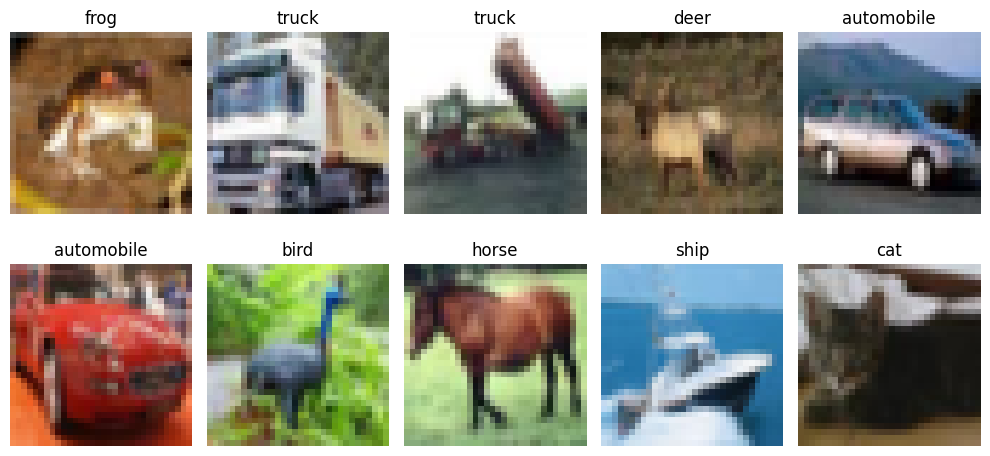

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Input(shape=(3072,)),

    layers.Dense(1024, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),

    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 54s 72ms/step - accuracy: 0.3583 - loss: 1.8108 - val_accuracy: 0.3640 - val_loss: 1.7798
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 73ms/step - accuracy: 0.4178 - loss: 1.6328 - val_accuracy: 0.3844 - val_loss: 1.7450
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.4382 - loss: 1.5721 - val_accuracy: 0.4320 - val_loss: 1.6196
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.4532 - loss: 1.5354 - val_accuracy: 0.3978 - val_loss: 1.7534
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 75ms/step - accuracy: 0.4592 - loss: 1.5098 - val_accuracy: 0.3868 - val_loss: 1.7093
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 72ms/step - accuracy: 0.4688 - loss: 1.4792 - val_accuracy: 0.4690 - val_loss: 1.5092
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 72ms/step - accuracy: 0.4830 - loss: 1.4526 - val_accuracy: 0.4334 - val_loss: 1.5992
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 71ms/step - accuracy: 0.4844 - loss: 1.4401 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4699 - loss: 1.4906
ANN Test Accuracy: 0.4699000120162964


### ANN Experiment Summary

I tested different ANN configurations to improve the CIFAR-10 baseline accuracy. The first model used Dropout after all hidden layers, but it gave the lowest accuracy of **36.84%**, likely because too much Dropout caused underfitting.

After reducing Dropout to only the first layer, the accuracy improved to **43.22%**. Then, using lighter Dropout of `0.2` after the first two Dense layers improved the result further to **45.56%**.

The best result came after adding Batch Normalization after the Dense layers. This model reached **46.99% test accuracy** with a test loss of **1.4906**. Overall, Batch Normalization gave the best ANN performance among the tested configurations.

| Experiment | Model Change | Test Accuracy | Test Loss |
|---|---|---:|---:|
| 1 | Dropout after all hidden layers | 36.84% | 1.8130 |
| 2 | Dropout only after first Dense layer | 43.22% | 1.6562 |
| 3 | Dropout after first two Dense layers | 45.56% | 1.5417 |
| 4 | Batch Normalization after Dense layers | 46.99% | 1.4906 |

# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 435s 609ms/step - accuracy: 0.5540 - loss: 1.2906 - val_accuracy: 0.6264 - val_loss: 1.0561
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 432s 614ms/step - accuracy: 0.7189 - loss: 0.8051 - val_accuracy: 0.7264 - val_loss: 0.7864
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 439s 609ms/step - accuracy: 0.7748 - loss: 0.6432 - val_accuracy: 0.7644 - val_loss: 0.6979
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 435s 617ms/step - accuracy: 0.8140 - loss: 0.5349 - val_accuracy: 0.7420 - val_loss: 0.7747
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 438s 613ms/step - accuracy: 0.8440 - loss: 0.4457 - val_accuracy: 0.7644 - val_loss: 0.7063
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 441s 627ms/step - accuracy: 0.8726 - loss: 0.3698 - val_accuracy: 0.8012 - val_loss: 0.6092
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 426s 605ms/step - accuracy: 0.8963 - loss: 0.2953 - val_accuracy: 0.8022 - val_loss: 0.6238
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 449s 615ms/step - accuracy: 0.9157 -

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.7734 - loss: 0.8508
CNN Test Accuracy: 0.7734000086784363


### CNN Experiment Summary

The CNN model was improved by increasing the convolution blocks using the filter pattern `32 → 64 → 128`. I also added two `Conv2D` layers in each block before applying `MaxPooling2D`, which helped the model learn stronger spatial features from the CIFAR-10 images.

The earlier CNN model achieved a test accuracy of **75.19%**. After improving the CNN architecture, the test accuracy increased to **77.34%**, giving an improvement of about **2.15 percentage points**.

The best validation accuracy during training was **80.60% at epoch 8**, but by epoch 10 the validation accuracy dropped to **78.06%**, while training accuracy increased to **94.24%**. This shows that the model started to overfit near the end of training. Because of this, using EarlyStopping in the next augmented CNN model is useful.

## 📈 Compare Learning Curves

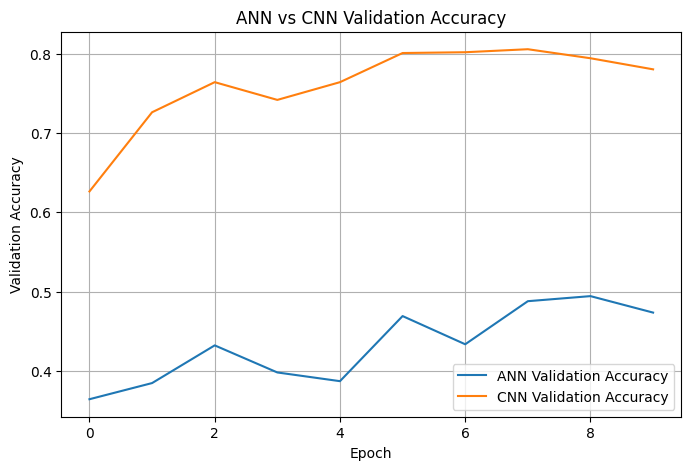

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(ann_history.history['val_accuracy'], label='ANN Validation Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Validation Accuracy')

plt.title('ANN vs CNN Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()

### ANN vs CNN Validation Accuracy Curve

The validation accuracy curve shows that the CNN model performs much better than the ANN model on CIFAR-10. The ANN model uses flattened image vectors, so it loses spatial information from the images. In contrast, the CNN model uses convolution layers, which help it learn spatial features such as edges, shapes, and object patterns.

The ANN reached a test accuracy of **46.99%**, while the CNN reached **77.34%**. This shows that CNN is more suitable for image classification tasks.

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
from tensorflow.keras import callbacks

data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

augmented_cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

augmented_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

augmented_history = augmented_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 466s 651ms/step - accuracy: 0.4532 - loss: 1.5706 - val_accuracy: 0.5574 - val_loss: 1.2944
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 454s 644ms/step - accuracy: 0.5956 - loss: 1.1427 - val_accuracy: 0.6304 - val_loss: 1.0951
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 505s 648ms/step - accuracy: 0.6553 - loss: 0.9788 - val_accuracy: 0.6714 - val_loss: 0.9923
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 443s 629ms/step - accuracy: 0.6914 - loss: 0.8822 - val_accuracy: 0.6784 - val_loss: 0.9640
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 448s 637ms/step - accuracy: 0.7173 - loss: 0.8116 - val_accuracy: 0.7252 - val_loss: 0.7994
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 454s 644ms/step - accuracy: 0.7367 - loss: 0.7630 - val_accuracy: 0.7480 - val_loss: 0.7612
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 446s 634ms/step - accuracy: 0.7556 - loss: 0.7141 - val_accuracy: 0.7642 - val_loss: 0.7048
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 445s 632ms/step - accuracy: 0.7646 -

In [27]:
aug_test_loss, aug_test_acc = augmented_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)
print("Augmented CNN Test Loss:", aug_test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.8240 - loss: 0.5250
Augmented CNN Test Accuracy: 0.8240000009536743
Augmented CNN Test Loss: 0.5249629616737366


# 📊 Final Comparison Table

In [28]:
results_df = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc],
    "Test Loss": [ann_test_loss, cnn_test_loss, aug_test_loss]
})

results_df

,Model,Test Accuracy,Test Loss
0,ANN,0.4699,1.490551
1,CNN,0.7734,0.850773
2,Augmented CNN,0.8240,0.524963


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**